In [1]:
import torch
import numpy as np
from models.bvae import BetaVAE
from models.mlp import MLP
from dataset.vog_maze import VOGMaze2dOfflineRLDataset
from dataset.vog_maze_emb import VOGEmbeddingDataset
import sys
sys.path.append('../data_gen_scripts')

## 1. Load Model and Dataset

In [2]:
# load model & dataset\||
dataset_type = 'emb'

# path_to_model = './weights/vae_weight.pth'
# path_to_dataset  = './data/original_data'
path_to_model = './weights/e2s_weight.pth'
path_to_dataset  = './data/embedded_data'

if dataset_type == 'emb':
    model = MLP(8, 2)
    model.load_state_dict(torch.load(path_to_model))
    data = VOGEmbeddingDataset(dataset_url=path_to_dataset, split='validation')
    print('Dataset loaded')
else:    
    model = BetaVAE().to('cuda:0')
    model.load_state_dict(torch.load(path_to_model))
    model.eval()
    print('Model loaded')

    # load dataset - this will take a while
    data = VOGMaze2dOfflineRLDataset(dataset_url=path_to_dataset) 
    print('Dataset loaded')


/tmp/ipykernel_461393/2780672498.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path_to_model))


Dataset loaded


## 2. Visualize Map

8 8


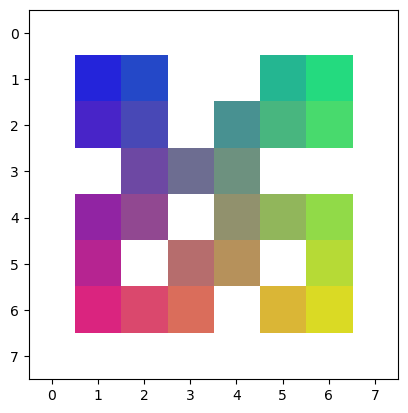

In [3]:
maze_type = 'medium'

def get_2d_colors(points, min_point, max_point):
    """Get colors corresponding to 2-D points."""
    points = np.array(points)
    min_point = np.array(min_point)
    max_point = np.array(max_point)

    colors = (points - min_point) / (max_point - min_point)
    colors = np.hstack((colors, (2 - np.sum(colors, axis=1, keepdims=True)) / 2))
    colors = np.clip(colors, 0, 1)
    colors = np.c_[colors, np.full(len(colors), 0.8)]

    return colors
if maze_type == 'medium':
    maze_map = [
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, 0, 0, 1, 1, 0, 0, 1],
        [1, 0, 0, 1, 0, 0, 0, 1],
        [1, 1, 0, 0, 0, 1, 1, 1],
        [1, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 1, 0, 0, 1, 0, 1],
        [1, 0, 0, 0, 1, 0, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ]
elif maze_type == 'large':
    maze_map = [
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
        [1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1],
        [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1],
        [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
        [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1],
        [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    ]
elif maze_type == 'giant':
    maze_map = [
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1],
        [1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1],
        [1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1],
        [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1],
        [1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1],
        [1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1],
        [1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1],
        [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    ]
elif maze_type == 'teleport':
    maze_map = [
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1],
        [1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1],
        [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1],
        [1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1],
        [1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    ]

height, width = len(maze_map), len(maze_map[0])
print(height, width)
map = np.zeros((height, width, 3))
for i in range(height):
    for j in range(width):
        if maze_map[i][j] == 1:
            map[i, j] = [1, 1, 1]
        else:
            map[i, j] = get_2d_colors([[i, j]], [0, 0], [height-1, width -1])[0, :3]

import matplotlib.pyplot as plt
plt.imshow(map)


In [4]:
def modify_pos(pos):
    pos_modif = pos / 4 + 1
    return pos_modif

def unnormalize_pos(pos):
    # Normalizations
    pos_mean = np.array([10.273524, 9.648321])
    pos_std = np.array([5.627576, 4.897987])
    pos_unnorm = pos * pos_std + pos_mean
    return pos_unnorm

## Plot e2s

In [5]:
import imageio
import cv2
frames = []
for i in range(0 ,5001, 50):
    emb, pos, act = data.__getitem__(i)
    pos_est = modify_pos(unnormalize_pos(model(emb).detach().numpy()))
    pos = modify_pos(unnormalize_pos(pos))

    fig, ax = plt.subplots()
    ax.imshow(map)
    ax.scatter(pos_est[0], pos_est[1], c='red', s=20, label='Estimated', alpha=0.8)
    ax.scatter(pos[0], pos[1], c='blue', s=20, label='True', alpha=0.8)
    ax.invert_yaxis()
    ax.legend()

    plt.savefig('temp_points.png')
    plt.close(fig)

    frame = cv2.imread('temp_points.png')
    frames.append(frame)

imageio.mimsave('embed_2_pos.gif', frames, fps=1)
cv2.destroyAllWindows()

/tmp/ipykernel_461393/217026334.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pos_unnorm = pos * pos_std + pos_mean



## Plot

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import imageio
from tqdm import tqdm

# Update font size
plt.rcParams.update({'font.size': 24})

# Function to calculate L2 distance
def l2_distance(a, b):
    return np.linalg.norm(a - b)

# Create a list to store frames
frames = []

# 예시) 전체 맵 이미지 불러오기
base_idx = 1001
base_obs, base_pos = data.__getitem__(base_idx)
base_obs = base_obs.unsqueeze(0)  # (1, C, H, W)
base_emb = model.encode(base_obs.to('cuda:0'))[0].detach().cpu().numpy()
base_pos_x, base_pos_y = modify_pos(base_pos)

max_latent_l2_dist = 0
max_pos_l2_dist = 0

# find max l2 distance
for i in tqdm(range(base_idx, base_idx + 501, 5)):
    obs, pos = data.__getitem__(i)
    obs = obs.unsqueeze(0)  # (1, C, H, W)
    pos_l2_dist = l2_distance(pos, base_pos) 
    latent = model.encode(obs.to('cuda:0'))[0].detach().cpu().numpy() 
    latent_l2_dist = l2_distance(latent, base_emb) 
    max_latent_l2_dist = max(max_latent_l2_dist, latent_l2_dist)
    max_pos_l2_dist = max(max_pos_l2_dist, pos_l2_dist)

100%|██████████| 101/101 [00:00<00:00, 1052.39it/s]


In [7]:
for i in tqdm(range(base_idx, base_idx + 501, 5)):
    # 새 Figure & Subplots
    fig, axs = plt.subplots(1, 4, figsize=(24, 9))

    # -------------------------------
    # 1) 전체 맵 + 시작 위치 + 현재 위치
    # -------------------------------
    # (예시) full_map 을 첫 번째 subplot 에 표시
    axs[0].imshow(map)
    axs[0].set_title('Entire Map')

    # i번째 data
    obs, pos = data.__getitem__(i)
    
    # 시작 위치, 현재 위치를 맵 상에 찍기
    # ※ base_pos, pos 의 좌표계가 full_map 상의 (x, y) 픽셀 좌표와 같아야 제대로 표시됩니다.
    pos_x, pos_y = modify_pos(pos)
    axs[0].scatter(base_pos_x, base_pos_y, color='red', s=200, marker='o', label="Base Position")
    axs[0].scatter(pos_x, pos_y, color='blue', s=200, marker='o', label="Current Position")
    axs[0].invert_yaxis()
    # -------------------------------
    # 2) 관측 이미지(Observation) 표시
    # -------------------------------
    obs_unnormalized = (obs * 71.0288272312382 + 141.785487953533) / 255.0
    obs_unnormalized = obs_unnormalized.permute(1, 2, 0).numpy()
    axs[1].imshow(cv2.cvtColor(obs_unnormalized, cv2.COLOR_BGR2RGB))
    axs[1].set_title(f'Observation {i - base_idx}')

    # -------------------------------
    # 3) Reconstruction 이미지 표시
    # -----------------------------
    with torch.no_grad():
        recon, _, mu, log_var = model(obs.unsqueeze(0).to('cuda:0'))
        recon_normalized = (recon * 71.0288272312382 + 141.785487953533) / 255.0
        recon_normalized = recon_normalized.squeeze(0).permute(1, 2, 0).cpu().numpy()
        axs[2].imshow(cv2.cvtColor(recon_normalized, cv2.COLOR_BGR2RGB))
        axs[2].set_title(f'Reconstruction {i - base_idx}')

    # -------------------------------
    # 4) L2 Distance 막대 그래프
    # -------------------------------
    obs = obs.unsqueeze(0)  # (1, C, H, W)
    pos_l2_dist = l2_distance(pos, base_pos) / max_pos_l2_dist
    latent = model.reparameterize(mu, log_var).detach().cpu().numpy() 
    latent_l2_dist = l2_distance(latent, base_emb)  / max_latent_l2_dist 
    axs[3].bar(['Position', 'Latent'],
               [pos_l2_dist, latent_l2_dist],
               color=['blue', 'red'])
    axs[3].set_ylim(0, 1)
    axs[3].set_title('L2 Distances (Normalized)')

    plt.savefig('temp_plot.png')
    plt.close(fig)

    frame = cv2.imread('temp_plot.png')
    if 340 < (i - base_idx) < 365:        
        cv2.imwrite(f'frame_{i-base_idx}.png', cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    frames.append(frame)

imageio.mimsave(f'{path_to_model}.gif', frames, fps=5)
cv2.destroyAllWindows()

100%|██████████| 101/101 [00:21<00:00,  4.67it/s]


In [8]:
max_latent_l2_dist, max_pos_l2_dist

(np.float32(12.780803), np.float32(20.188135))

## Observations

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import imageio

# Update font size
plt.rcParams.update({'font.size': 24})

# Function to calculate L2 distance
def l2_distance(a, b):
    return np.linalg.norm(a - b)

# Create a list to store frames
frames = []

# 예시) 전체 맵 이미지 불러오기
base_idx = 1001
base_obs, base_pos = data.__getitem__(base_idx)
base_obs = base_obs.unsqueeze(0)  # (1, C, H, W)
base_obs_unnormalized = (base_obs.detach().squeeze().permute(1, 2, 0).cpu().numpy() * 71.0288272312382 + 141.785487953533) / 255.0
base_pos_x, base_pos_y = modify_pos(base_pos)
max_obs_l2_dist = 215.95131
max_pos_l2_dist = 27.16741

prev_obs_l2_dist = 0
prev_pos_l2_dist = 0
max_obs_diff = 0.42555568
max_pos_diff = 0.07089323
from tqdm import tqdm
for i in tqdm(range(base_idx, base_idx + 501, 5)):
    # 새 Figure & Subplots
    fig, axs = plt.subplots(1, 5, figsize=(34, 9))

    # # -------------------------------
    # # 1) 전체 맵 + 시작 위치 + 현재 위치
    # # -------------------------------
    # # (예시) full_map 을 첫 번째 subplot 에 표시
    axs[0].imshow(map)
    axs[0].set_title('Entire Map')

    # # i번째 data
    obs, pos = data.__getitem__(i)
    
    # # 시작 위치, 현재 위치를 맵 상에 찍기
    # # ※ base_pos, pos 의 좌표계가 full_map 상의 (x, y) 픽셀 좌표와 같아야 제대로 표시됩니다.
    pos_x, pos_y = modify_pos(pos)
    axs[0].scatter(base_pos_x, base_pos_y, color='red', s=200, marker='o', label="Base Position")
    axs[0].scatter(pos_x, pos_y, color='blue', s=200, marker='o', label="Current Position")
    axs[0].invert_yaxis()

    # -------------------------------
    # 2) 시작 위치
    # -------------------------------
    axs[1].imshow(cv2.cvtColor(base_obs_unnormalized, cv2.COLOR_BGR2RGB))
    axs[1].set_title(f'Start')

    # -------------------------------
    # 2) 관측 이미지(Observation) 표시
    # -------------------------------    
    obs_unnormalized = (obs * 71.0288272312382 + 141.785487953533) / 255.0
    obs_unnormalized = obs_unnormalized.squeeze().permute(1, 2, 0).numpy()
    axs[2].imshow(cv2.cvtColor(obs_unnormalized, cv2.COLOR_BGR2RGB))
    obs.unsqueeze(0)
    pos_l2_dist = l2_distance(pos, base_pos) / max_pos_l2_dist
    obs_l2_dist = l2_distance(obs, base_obs) / max_obs_l2_dist
    axs[2].set_title(f'Current')

    # -------------------------------
    # 3) 차이
    # -----------------------------
    obs_diff = np.abs(obs_unnormalized - base_obs_unnormalized)
    obs_diff = (obs_diff - np.min(obs_diff)) / (np.max(obs_diff) - np.min(obs_diff))
    axs[3].imshow(cv2.cvtColor(obs_diff, cv2.COLOR_BGR2GRAY), cmap='gray')
    axs[3].set_title(f'OBS Difference')

    # -------------------------------
    # 3) L2 Distance 막대 그래프
    # -------------------------------
    # obs = obs.unsqueeze(0)  # (1, C, H, W)

    pos_l2_dist = l2_distance(pos, base_pos) / max_pos_l2_dist
    obs_l2_dist = l2_distance(obs, base_obs) / max_obs_l2_dist
    max_obs_l2_dist = max(max_obs_l2_dist, obs_l2_dist)
    axs[4].bar(['Position', 'Pixel'],
               [pos_l2_dist, obs_l2_dist],
               color=['blue', 'red'])
    axs[4].set_ylim(0, 1)
    axs[4].set_title('L2 Distances (Normalized)')

    # -------------------------------
    # 4) l2 distance 증감 그래프
    # -----------------------------
    # obs_diff = obs_l2_dist - prev_obs_l2_dist
    # pos_diff = pos_l2_dist - prev_pos_l2_dist
    # axs[3].bar(['Position', 'Pixel', 'Correlation'],
    #            [pos_diff / max_pos_diff, obs_diff / max_obs_diff, 1 if pos_diff * obs_diff > 0 else -1],
    #            color=['green', 'yellow', 'red' if pos_diff * obs_diff > 0 else 'blue'])
    # axs[3].set_ylim(-1, 1)
    # axs[3].set_title('L2 Distances (Change)')
    # prev_obs_l2_dist = obs_l2_dist
    # prev_pos_l2_dist = pos_l2_dist

    plt.savefig('temp_plot.png')
    plt.close(fig)

    frame = cv2.imread('temp_plot.png')
    # if 340 < (i - base_idx) < 365:        
    #     cv2.imwrite(f'frame_{i-base_idx}.png', cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    frames.append(frame)

imageio.mimsave(f'obs.gif', frames, fps=5)
cv2.destroyAllWindows()

  0%|          | 0/101 [00:00<?, ?it/s]/tmp/ipykernel_3076281/4014220092.py:72: RuntimeWarning: invalid value encountered in divide
  obs_diff = (obs_diff - np.min(obs_diff)) / (np.max(obs_diff) - np.min(obs_diff))
100%|██████████| 101/101 [00:27<00:00,  3.72it/s]


In [10]:
max_obs_diff, max_pos_diff

(0.42555568, 0.07089323)

In [11]:
max_obs_l2_dist

215.95131